# 04b - Semi-supervised Learning (Bán giám sát)

Mục tiêu của nhánh thực nghiệm này:

1. **Giả lập thiếu nhãn**: chỉ giữ lại p=20% nhãn trên tập train, phần còn lại gán là **unlabeled**.
2. Triển khai **Self-training** (và tùy chọn **Label Spreading**) để tận dụng dữ liệu không nhãn.
3. So sánh với **Supervised-only** (chỉ học trên p nhãn) và vẽ **Learning Curve** theo tỉ lệ nhãn.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier, LabelSpreading
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

sns.set(style="whitegrid")

ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

with open("../configs/params.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

RANDOM_SEED = int(cfg.get("random_seed", 42))
p_default = float(cfg.get("semi_supervised", {}).get("labeled_fraction", 0.2))

paths_cfg = cfg.get("paths", {})
cleaned_path = (ROOT_DIR / paths_cfg.get("cleaned_data", "data/processed/cleaned.csv")).resolve()
print("Cleaned data path:", cleaned_path)


Cleaned data path: E:\DLL\btl\data\processed\cleaned.csv


In [2]:
# Load dữ liệu sạch
df = pd.read_csv(
    cleaned_path,
    encoding="ISO-8859-1",
    parse_dates=["InvoiceDate"],
    dtype={"InvoiceNo": str, "StockCode": str},
)

# Target
if "is_return" not in df.columns:
    raise ValueError("Thiếu cột is_return trong cleaned.csv. Hãy chạy notebook 02 hoặc DataCleaner trước.")

# Feature đơn giản, tránh leakage: chỉ dùng thông tin tại thời điểm hóa đơn
df["HourOfDay"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["Month"] = df["InvoiceDate"].dt.month

feature_cols = [
    "Quantity",
    "UnitPrice",
    "HourOfDay",
    "DayOfWeek",
    "Month",
    "Country",
]

X = df[feature_cols].copy()
y = df["is_return"].astype(int).values

print("Shape X:", X.shape)
print("Return rate:", y.mean())


Shape X: (406789, 6)
Return rate: 0.021890955753474158


In [3]:
# Chia train/test cố định để so sánh công bằng
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=float(cfg.get("modeling", {}).get("test_size", 0.2)),
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train return rate:", y_train.mean(), "Test return rate:", y_test.mean())


Train: (325431, 6) Test: (81358, 6)
Train return rate: 0.021890969206990116 Test return rate: 0.021890901939575703


## 1) Giả lập thiếu nhãn p=20%

Ta sẽ giữ lại ngẫu nhiên p nhãn trong tập train, phần còn lại gán nhãn **-1** (unlabeled) theo chuẩn scikit-learn.


In [4]:
def make_semi_supervised_labels(y_true: np.ndarray, labeled_fraction: float, seed: int) -> np.ndarray:
    rng = np.random.RandomState(seed)
    y_semi = y_true.copy().astype(int)
    mask_labeled = rng.rand(len(y_true)) < labeled_fraction
    y_semi[~mask_labeled] = -1
    return y_semi


p = p_default
y_train_semi = make_semi_supervised_labels(y_train, labeled_fraction=p, seed=RANDOM_SEED)

print("Labeled fraction (actual):", (y_train_semi != -1).mean())
print("Unlabeled count:", int((y_train_semi == -1).sum()))


Labeled fraction (actual): 0.199523093989202
Unlabeled count: 260500


## 2) Supervised-only (chỉ dùng 20% nhãn) vs Semi-supervised

Ta so sánh 2 hướng:

- **Supervised-only**: chỉ fit trên phần có nhãn (20% train), bỏ qua unlabeled.
- **Self-training**: fit trên cả train với unlabeled, mô hình sẽ tự gán pseudo-label cho những điểm có độ tin cậy cao.

Ghi chú: dùng pipeline `ColumnTransformer` để xử lý numeric + categorical (Country).


In [5]:
numeric_features = ["Quantity", "UnitPrice", "HourOfDay", "DayOfWeek", "Month"]
categorical_features = ["Country"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

base_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_SEED,
)

supervised_only = Pipeline(steps=[("preprocess", preprocess), ("clf", base_clf)])

self_training = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "clf",
            SelfTrainingClassifier(
                estimator=base_clf,
                threshold=0.8,
                criterion="threshold",
            ),
        ),
    ]
)

# Label Spreading (tùy chọn). Có thể tốn RAM nếu train quá lớn.
label_spreading = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", LabelSpreading(kernel="rbf", gamma=20, max_iter=30)),
    ]
)

def evaluate_binary(model, X_te, y_te):
    y_pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    f1 = f1_score(y_te, y_pred)
    roc = roc_auc_score(y_te, proba) if proba is not None else np.nan
    pr = average_precision_score(y_te, proba) if proba is not None else np.nan
    return {"f1": f1, "roc_auc": roc, "pr_auc": pr}


In [6]:
# Fit Supervised-only trên phần có nhãn
mask_labeled = y_train_semi != -1
X_train_lab = X_train.loc[mask_labeled]
y_train_lab = y_train[mask_labeled]

supervised_only.fit(X_train_lab, y_train_lab)
res_sup = evaluate_binary(supervised_only, X_test, y_test)
print("Supervised-only (p=20% labels):", res_sup)

# Fit Self-training trên toàn train (y=-1 cho unlabeled)
self_training.fit(X_train, y_train_semi)
res_self = evaluate_binary(self_training, X_test, y_test)
print("Self-training (p=20% labels):", res_self)

# (Tuỳ chọn) Label Spreading: bật nếu bạn muốn so sánh thêm
run_label_spreading = False
if run_label_spreading:
    label_spreading.fit(X_train, y_train_semi)
    res_ls = evaluate_binary(label_spreading, X_test, y_test)
    print("Label Spreading (p=20% labels):", res_ls)


Supervised-only (p=20% labels): {'f1': 0.0682076813655761, 'roc_auc': 0.6493706789924042, 'pr_auc': 0.04989568424747983}


Self-training (p=20% labels): {'f1': 0.07615700058582309, 'roc_auc': 0.6420640073467629, 'pr_auc': 0.04282672896921723}


## 3) Learning Curve theo tỉ lệ nhãn

Ta chạy nhiều mức p nhãn (tỉ lệ nhãn quan sát) và đo hiệu năng trên **test set cố định**.


In [7]:
label_fractions = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8]

rows = []
for frac in label_fractions:
    y_semi = make_semi_supervised_labels(y_train, labeled_fraction=frac, seed=RANDOM_SEED)
    mask = y_semi != -1
    X_lab = X_train.loc[mask]
    y_lab = y_train[mask]

    supervised_only.fit(X_lab, y_lab)
    r1 = evaluate_binary(supervised_only, X_test, y_test)
    rows.append({"method": "Supervised-only", "labeled_fraction": frac, **r1})

    self_training.fit(X_train, y_semi)
    r2 = evaluate_binary(self_training, X_test, y_test)
    rows.append({"method": "Self-training", "labeled_fraction": frac, **r2})

lc_df = pd.DataFrame(rows)
display(lc_df)


,method,labeled_fraction,f1,roc_auc,pr_auc
0,Supervised-only,0.05,0.068700,0.647006,0.049146
1,Self-training,0.05,0.078393,0.642655,0.044367
2,Supervised-only,0.10,0.068329,0.644631,0.047685
3,Self-training,0.10,0.073705,0.640169,0.042266
4,Supervised-only,0.20,0.068208,0.649371,0.049896
5,Self-training,0.20,0.076157,0.642064,0.042827
6,Supervised-only,0.40,0.069320,0.651101,0.051019
7,Self-training,0.40,0.079020,0.647909,0.044618
8,Supervised-only,0.60,0.069052,0.650583,0.051078
9,Self-training,0.60,0.079252,0.650312,0.045987


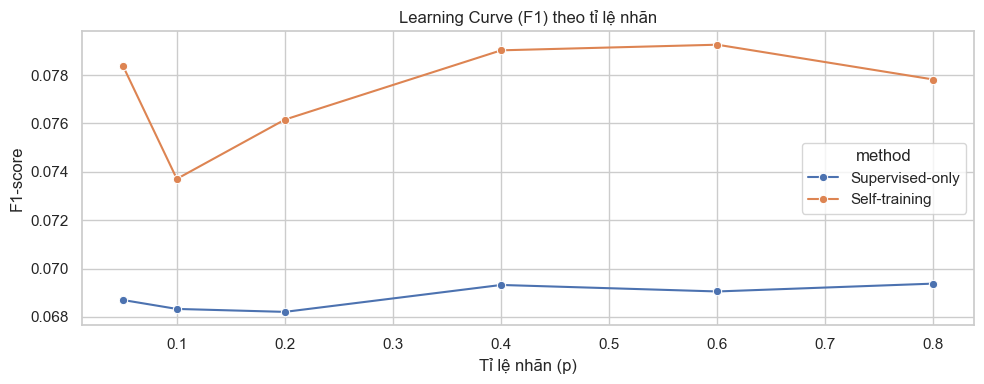

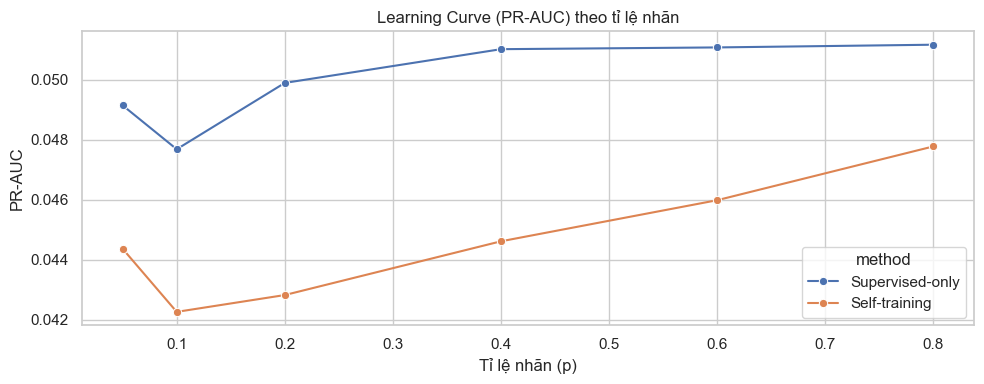

In [8]:
# Vẽ Learning Curve
plt.figure(figsize=(10, 4))
sns.lineplot(data=lc_df, x="labeled_fraction", y="f1", hue="method", marker="o")
plt.title("Learning Curve (F1) theo tỉ lệ nhãn")
plt.xlabel("Tỉ lệ nhãn (p)")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.lineplot(data=lc_df, x="labeled_fraction", y="pr_auc", hue="method", marker="o")
plt.title("Learning Curve (PR-AUC) theo tỉ lệ nhãn")
plt.xlabel("Tỉ lệ nhãn (p)")
plt.ylabel("PR-AUC")
plt.tight_layout()
plt.show()


## Phân tích rủi ro: Pseudo-label sai (rất quan trọng)

Kỹ thuật Self-training dựa trên giả định: mô hình ban đầu (học từ phần nhãn nhỏ) có thể dự đoán đúng một phần điểm unlabeled với độ tin cậy cao, sau đó dùng các dự đoán này làm pseudo-label để mở rộng tập huấn luyện.

**Rủi ro chính nếu pseudo-label bị sai:**

- **Khuếch đại lỗi (error amplification)**: mô hình tự "dạy" mình bằng nhãn sai; sai lệch có thể tăng dần qua các vòng.
- **Thiên lệch về lớp phổ biến**: lớp `is_return=1` thường hiếm; nếu mô hình ban đầu thiên về dự đoán 0 thì pseudo-label dễ làm mô hình càng khó học lớp 1.
- **Ngưỡng tin cậy không phù hợp**: threshold quá thấp nhận nhiều nhãn giả sai; threshold quá cao thì gần như không tận dụng được unlabeled.
- **Thay đổi hành vi theo thời gian (concept drift)**: pseudo-label sinh từ giai đoạn khác mùa có thể gây sai.

**Cách giảm rủi ro (gợi ý báo cáo):**

- Dùng **ngưỡng tin cậy cao** (ví dụ 0.8–0.95) và theo dõi số lượng mẫu được gán nhãn.
- Đánh giá bằng **PR-AUC** (nhạy với lớp hiếm) và F1 cho lớp trả hàng.
- Giới hạn độ phức tạp mô hình cơ sở, hoặc dùng calibration để xác suất đáng tin hơn.
- Dùng Label Spreading như đối chứng nếu phù hợp.
